In [8]:


import zipfile

with zipfile.ZipFile("ticket.zip", "r") as zip_ref:
    print(zip_ref.namelist())

['all_tickets_processed_improved_v3.csv']


In [5]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Shreshtha Pandey\IT ticket classifier
['.ipynb_checkpoints', 'data', 'ticket.zip', 'Untitled.ipynb']


In [10]:
import pandas as pd

df = pd.read_csv("data/all_tickets_processed_improved_v3.csv")


In [13]:
df.head()
df["Topic_group"].value_counts()

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

In [14]:
df.shape

(47837, 2)

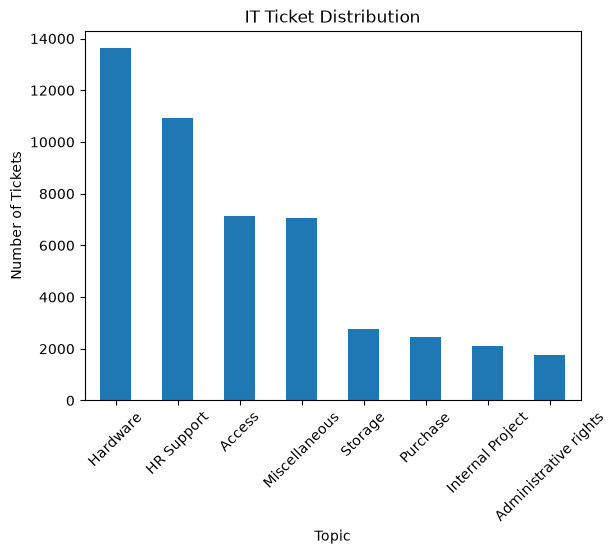

In [17]:
import matplotlib.pyplot as plt

df["Topic_group"].value_counts().plot(kind="bar")

plt.title("IT Ticket Distribution")
plt.xlabel("Topic")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

In [22]:
df.describe()

,Document,Topic_group
count,47837,47837
unique,47837,8
top,connection with icon icon dear please setup ic...,Hardware
freq,1,13617


In [25]:
df["Topic_group"].isna().sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
47832    False
47833    False
47834    False
47835    False
47836    False
Name: Topic_group, Length: 47837, dtype: bool>

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 14.5 MB


In [27]:
print(df.isnull().any().any())

False


In [28]:
print(df.duplicated().sum())

0


In [29]:
print(df.duplicated().any())

False


In [40]:
import re

df = df.dropna().drop_duplicates()

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"[^a-z\s]", " ", t)   # punctuation/numbers remove
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["Document"] = df["Document"].apply(clean_text)

In [46]:
df = df[df["Document"].str.split().str.len() >= 2]

In [48]:
df["Topic_group"] = df["Topic_group"].str.strip().str.lower()
print(df["Topic_group"].value_counts())

Topic_group
hardware                 13617
hr support               10915
access                    7125
miscellaneous             7060
storage                   2777
purchase                  2464
internal project          2119
administrative rights     1760
Name: count, dtype: int64


In [49]:
counts = df["Topic_group"].value_counts()
df = df[df["Topic_group"].isin(counts[counts >= 20].index)]

In [50]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,hardware
1,work experience user work experience user hi w...,access
2,requesting for meeting requesting meeting hi p...,hardware
3,reset passwords for external accounts re expir...,access
4,mail verification warning hi has got attached ...,miscellaneous


In [51]:
df.shape

(47837, 2)

In [54]:
print(df.columns.tolist())

['Document', 'Topic_group']


In [55]:
df = df.rename(columns={"Document": "text", "Topic_group": "category"})
# agar text column ka naam "Document" nahi hai, to upar wali line me sahi naam likho

df = df.dropna().drop_duplicates()
df["text"] = df["text"].astype(str).str.strip()
df["category"] = df["category"].str.strip().str.lower()

# bahut chhote tickets hatao
df = df[df["text"].str.split().str.len() >= 3]

print(df.shape)
print(df["category"].value_counts())

(47823, 2)
category
hardware                 13611
hr support               10911
access                    7124
miscellaneous             7058
storage                   2777
purchase                  2463
internal project          2119
administrative rights     1760
Name: count, dtype: int64


In [ ]:
#DATA CLEANING DONE

In [41]:
X = df["Document"]
y = df["Topic_group"]

In [44]:
from sklearn.model_selection import train_test_split

In [57]:


X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["category"],
    test_size=0.2, random_state=42, stratify=df["category"]
)
#This is important for your dataset because your classes are imbalanced.
#It ensures the proportion of each ticket category stays approximately the same in train and test.

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print(y_train.value_counts(normalize=True).round(3))

Train size: 38258
Test size: 9565
category
hardware                 0.285
hr support               0.228
access                   0.149
miscellaneous            0.148
storage                  0.058
purchase                 0.051
internal project         0.044
administrative rights    0.037
Name: proportion, dtype: float64


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("Train shape:", X_train_vec.shape)
print("Test shape:", X_test_vec.shape)

Train shape: (38258, 20000)
Test shape: (9565, 20000)


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced"),
}

results = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    pred = model.predict(X_test_vec)
    results[name] = f1_score(y_test, pred, average="macro")
    print(f"{name:20s} | Acc: {accuracy_score(y_test, pred):.3f} "
          f"| Weighted F1: {f1_score(y_test, pred, average='weighted'):.3f} "
          f"| Macro F1: {results[name]:.3f}")

Logistic Regression  | Acc: 0.864 | Weighted F1: 0.865 | Macro F1: 0.862
Naive Bayes          | Acc: 0.780 | Weighted F1: 0.774 | Macro F1: 0.733
Linear SVM           | Acc: 0.870 | Weighted F1: 0.870 | Macro F1: 0.869


In [63]:
from sklearn.metrics import classification_report

best_model = models["Linear SVM"]
pred = best_model.predict(X_test_vec)

print(classification_report(y_test, pred))

                       precision    recall  f1-score   support

               access       0.89      0.90      0.90      1425
administrative rights       0.75      0.81      0.78       352
             hardware       0.87      0.85      0.86      2722
           hr support       0.88      0.88      0.88      2182
     internal project       0.87      0.87      0.87       424
        miscellaneous       0.82      0.84      0.83      1412
             purchase       0.95      0.91      0.93       493
              storage       0.90      0.90      0.90       555

             accuracy                           0.87      9565
            macro avg       0.87      0.87      0.87      9565
         weighted avg       0.87      0.87      0.87      9565



In [ ]:
# Sabse kamzor category: administrative rights
# Precision 0.75 aur recall 0.81 hai, matlab model ne kuch non-admin tickets ko galti se "administrative rights" bol diya.
# Wajah: ye sabse chhoti class hai (sirf 352 test tickets), aur iske words access category se milte-julte hain (jaise "permission", "rights", "login").
# Ye hi aapki interview story hai: "Model sabse zyada administrative rights aur access ke beech confuse hota tha." Confusion matrix se hum ye prove karenge.

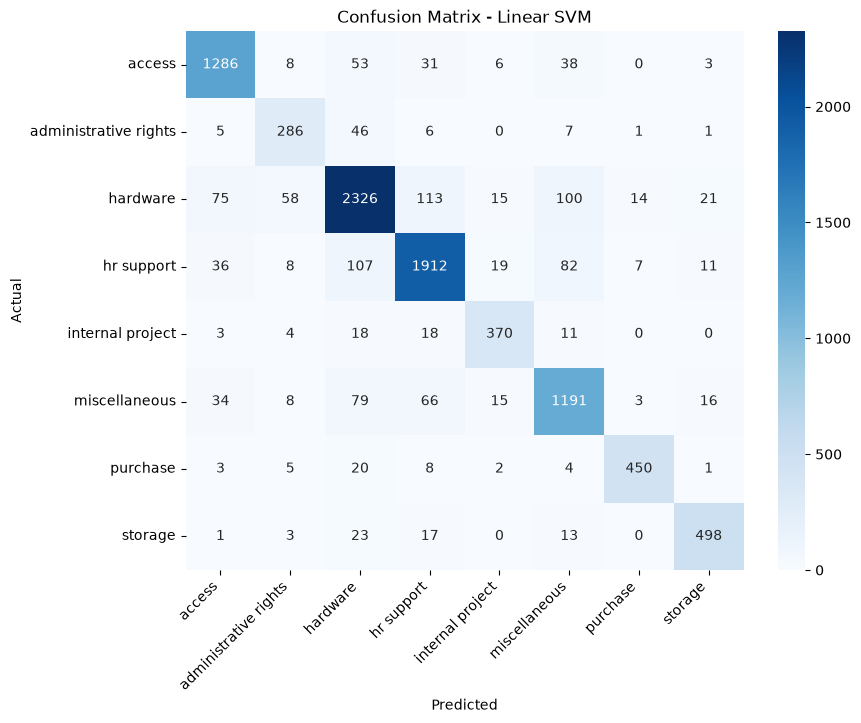

In [64]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred, labels=best_model.classes_)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.title("Confusion Matrix - Linear SVM")
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

In [65]:
import joblib

joblib.dump(best_model, "ticket_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

def predict_ticket(text):
    vec = tfidf.transform([text.lower()])
    return best_model.predict(vec)[0]

print(predict_ticket("access card deactivation please disable building"))
print(predict_ticket("purchase order approval invoice"))
print(predict_ticket("laptop screen broken keyboard not working"))

access
miscellaneous
hardware


In [66]:
sample = X_test[y_test == "purchase"].head(10)

for text, actual in zip(sample, y_test[sample.index]):
    print("Predicted:", predict_ticket(text), "| Actual:", actual)
    print("Text:", text[:150], "\n")

Predicted: purchase | Actual: purchase
Text: new purchase po thursday march pm purchase po dear purchased monitor please log installation please take consideration mandatory receipts section orde 

Predicted: purchase | Actual: purchase
Text: new purchase po tuesday pm purchase po dear purchased description quantity patch panel cat adaptor cat corning tub material si please log installation 

Predicted: internal project | Actual: purchase
Text: import of final for into import final dear please assign thank kind regards analyst 

Predicted: purchase | Actual: purchase
Text: wednesday march pm hi lr batteries floor requested by please create replenishment by please perform order thank help please follow tutorial thanks adm 

Predicted: purchase | Actual: purchase
Text: new purchase po purchase po dear purchased please log allocation after receive item please take consideration mandatory receipts section order receive 

Predicted: purchase | Actual: purchase
Text: new purchase po purchase

In [67]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [69]:
print(X_test[y_test == "hardware"].iloc[0])


for account needed for notes hi myself had few meetings inside regarding which leading had has invited meeting since expect more meetings where he present file thanks


In [70]:
print(X_test[y_test == "storage"].iloc[0])

reinstallation of outlook archive reinstallation archive dear reinstallation since option keep besides archive which talked out he reinstall kind regards specialist


In [71]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

rows = []
for name, model in models.items():
    pred = model.predict(X_test_vec)
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision (macro)": round(precision_score(y_test, pred, average="macro"), 3),
        "Recall (macro)": round(recall_score(y_test, pred, average="macro"), 3),
        "Weighted F1": round(f1_score(y_test, pred, average="weighted"), 3),
        "Macro F1": round(f1_score(y_test, pred, average="macro"), 3),
    })

import pandas as pd
results_df = pd.DataFrame(rows).sort_values("Macro F1", ascending=False)
print(results_df.to_markdown(index=False))

| Model               |   Accuracy |   Precision (macro) |   Recall (macro) |   Weighted F1 |   Macro F1 |
|:--------------------|-----------:|--------------------:|-----------------:|--------------:|-----------:|
| Linear SVM          |      0.87  |               0.867 |            0.871 |         0.87  |      0.869 |
| Logistic Regression |      0.864 |               0.846 |            0.884 |         0.865 |      0.862 |
| Naive Bayes         |      0.78  |               0.879 |            0.68  |         0.774 |      0.733 |


In [72]:
from sklearn.metrics import classification_report

best_model = models["Linear SVM"]
pred = best_model.predict(X_test_vec)

report = classification_report(y_test, pred, output_dict=True)
class_df = pd.DataFrame(report).T.round(3)
class_df = class_df.drop(index=["accuracy"], errors="ignore")
class_df["support"] = class_df["support"].astype(int)
print(class_df.to_markdown())

|                       |   precision |   recall |   f1-score |   support |
|:----------------------|------------:|---------:|-----------:|----------:|
| access                |       0.891 |    0.902 |      0.897 |      1425 |
| administrative rights |       0.753 |    0.812 |      0.781 |       352 |
| hardware              |       0.871 |    0.855 |      0.862 |      2722 |
| hr support            |       0.881 |    0.876 |      0.878 |      2182 |
| internal project      |       0.867 |    0.873 |      0.87  |       424 |
| miscellaneous         |       0.824 |    0.843 |      0.833 |      1412 |
| purchase              |       0.947 |    0.913 |      0.93  |       493 |
| storage               |       0.904 |    0.897 |      0.901 |       555 |
| macro avg             |       0.867 |    0.871 |      0.869 |      9565 |
| weighted avg          |       0.87  |    0.87  |      0.87  |      9565 |


In [73]:
import os, joblib

print("Total tickets (after cleaning):", len(df))
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Number of categories:", df["category"].nunique())
print("TF-IDF features:", len(tfidf.vocabulary_))
print("Avg words per ticket:", round(df["text"].str.split().str.len().mean(), 1))

print("\nClass distribution (%):")
print((df["category"].value_counts(normalize=True) * 100).round(1))

for f in ["ticket_model.pkl", "tfidf.pkl"]:
    if os.path.exists(f):
        print(f, "size (MB):", round(os.path.getsize(f) / 1e6, 2))
        

Total tickets (after cleaning): 47823
Train size: 38258 | Test size: 9565
Number of categories: 8
TF-IDF features: 20000
Avg words per ticket: 43.6

Class distribution (%):
category
hardware                 28.5
hr support               22.8
access                   14.9
miscellaneous            14.8
storage                   5.8
purchase                  5.2
internal project          4.4
administrative rights     3.7
Name: proportion, dtype: float64
ticket_model.pkl size (MB): 1.28
tfidf.pkl size (MB): 0.82


In [74]:
from sklearn.metrics import confusion_matrix
import numpy as np

labels = best_model.classes_
cm = confusion_matrix(y_test, pred, labels=labels)

errors = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            errors.append((labels[i], labels[j], cm[i][j]))

errors_df = pd.DataFrame(errors, columns=["Actual", "Predicted", "Count"])
print(errors_df.sort_values("Count", ascending=False).head(8).to_markdown(index=False))

| Actual        | Predicted             |   Count |
|:--------------|:----------------------|--------:|
| hardware      | hr support            |     113 |
| hr support    | hardware              |     107 |
| hardware      | miscellaneous         |     100 |
| hr support    | miscellaneous         |      82 |
| miscellaneous | hardware              |      79 |
| hardware      | access                |      75 |
| miscellaneous | hr support            |      66 |
| hardware      | administrative rights |      58 |


In [75]:
import time

start = time.time()
best_model.predict(X_test_vec)
total = time.time() - start
print(f"{len(y_test)} tickets predicted in {total:.3f} sec")
print(f"Per ticket: {total / len(y_test) * 1000:.3f} ms")

9565 tickets predicted in 0.021 sec
Per ticket: 0.002 ms


In [77]:
with open(".gitignore", "w") as f:
    f.write("""__pycache__/
.ipynb_checkpoints/
*.pyc
.env

data/
*.zip
""")

In [78]:
print(open(".gitignore").read())

__pycache__/
.ipynb_checkpoints/
*.pyc
.env

data/
*.zip

